In [9]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
df = pd.read_csv("../dataset/cleaned_traffic_data.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 2000
Columns: 12


In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month

weather_mapping = {
    "Sunny": 0,
    "Cloudy": 1,
    "Rainy": 2,
    "Foggy": 3,
    "Windy": 4
}

signal_mapping = {
    "Red": 0,
    "Yellow": 1,
    "Green": 2
}

df["weather_condition"] = df["weather_condition"].map(weather_mapping)
df["signal_status"] = df["signal_status"].map(signal_mapping)

features = [
    "location_id",
    "traffic_volume",
    "avg_vehicle_speed",
    "vehicle_count_cars",
    "vehicle_count_trucks",
    "vehicle_count_bikes",
    "weather_condition",
    "temperature",
    "humidity",
    "accident_reported",
    "hour",
    "minute",
    "day",
    "month"
]

X = df[features]
y = df["signal_status"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2000, 14)
Target: (2000,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 14)
Testing data: (400, 14)


In [13]:
model = joblib.load("../model/random_forest_model.pkl")

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [14]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.32
Accuracy Percentage: 32.0 %


In [15]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Red", "Yellow", "Green"]
))

              precision    recall  f1-score   support

         Red       0.32      0.34      0.33       136
      Yellow       0.32      0.38      0.35       142
       Green       0.31      0.23      0.27       122

    accuracy                           0.32       400
   macro avg       0.32      0.32      0.31       400
weighted avg       0.32      0.32      0.32       400



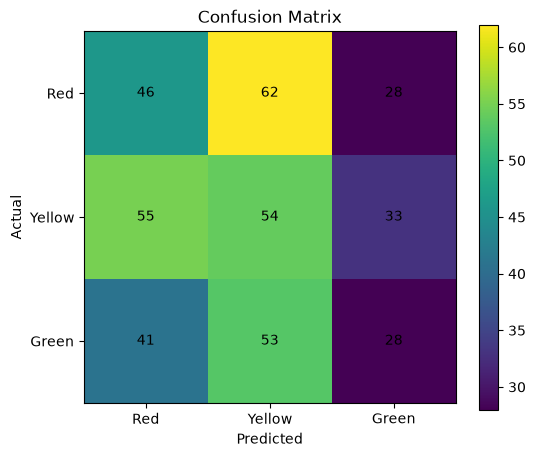

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks([0, 1, 2], ["Red", "Yellow", "Green"])
plt.yticks([0, 1, 2], ["Red", "Yellow", "Green"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()